In [1]:
import ROOT
MxCut = ROOT.TCut("0.85<Mx&&Mx<1.05")
WCut = ROOT.TCut("W>2")
yCut = ROOT.TCut("y<0.8")
xFCut = ROOT.TCut("xF>0")

In [2]:
f = ROOT.TFile("out/test/LUND_clasdis_rga_fa18_inb_45nA_10604MeV-0001.root")
f.ls()

TFile**		out/test/LUND_clasdis_rga_fa18_inb_45nA_10604MeV-0001.root	
 TFile*		out/test/LUND_clasdis_rga_fa18_inb_45nA_10604MeV-0001.root	
  KEY: TTree	EventTree;5	LUND-derived event tree [current cycle]
  KEY: TTree	EventTree;4	LUND-derived event tree [backup cycle]


In [3]:
t = f.Get("EventTree")
print(f"LUND file Tree: {t.GetEntries()}")

data = ROOT.TFile("/lustre24/expphy/volatile/clas12/users/tjhellst/cache/filtered_tree_pippi0_merged_in_pass2_MhChi2_MhFit_cthbin0_-1.000000_1.000000_MinPhoE_0.200000.root")

pippi0 = data.Get("pippi0")

print(f"Data pippi0: {pippi0.GetEntries()}")


LUND file Tree: 1701094
Data pippi0: 981540


In [4]:
[b.GetName() for b in t.GetListOfBranches()]

['Mh',
 'Mdiphoton',
 'rho_M',
 'rho_phi',
 'pion_M',
 't',
 'Q2',
 'Mx',
 'W',
 'y',
 'neutron_parent_pindex',
 'neutron_parent_pid',
 'xF',
 'z']

In [5]:
phi_bns = [-3.14,-2.36,-1.57,-0.79,0,0.79,1.57,2.36,3.14]

nbins = len(phi_bns)-1
baseColor = 51
histograms = []
for i in range(nbins):
    print(f"loading bin {i+1}")
    binCut = f"{phi_bns[i]}<rho_phi&&rho_phi<{phi_bns[i+1]}"
    cut = binCut
    t.Draw(f"rho_M>>h{i}(100,0.4,1.4)",cut,"goff")
    hist = ROOT.gDirectory.Get(f"h{i}")
    hist.SetLineWidth(2)
    histograms.append(hist)
    print(f"Percent of total Events: {round(hist.GetEntries() / t.GetEntries()*100,1)} % ")

loading bin 1
Percent of total Events: 12.4 % 
loading bin 2
Percent of total Events: 12.6 % 
loading bin 3
Percent of total Events: 12.4 % 
loading bin 4
Percent of total Events: 12.6 % 
loading bin 5
Percent of total Events: 12.6 % 
loading bin 6
Percent of total Events: 12.4 % 
loading bin 7
Percent of total Events: 12.6 % 
loading bin 8
Percent of total Events: 12.4 % 


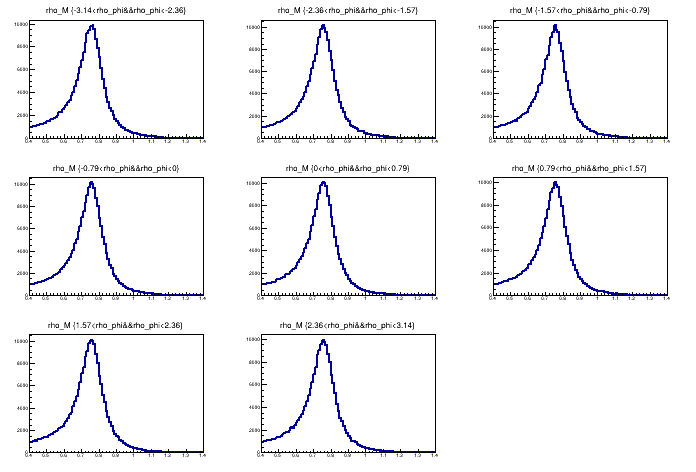

In [6]:
c = ROOT.TCanvas()
c.Divide(3,3)
draw_opt = "HIST"
for i in range(8):
    c.cd(i+1)
    histograms[i].SetStats(0)
    histograms[i].Draw(draw_opt)
    draw_opt = "HIST SAME"

c.Draw()

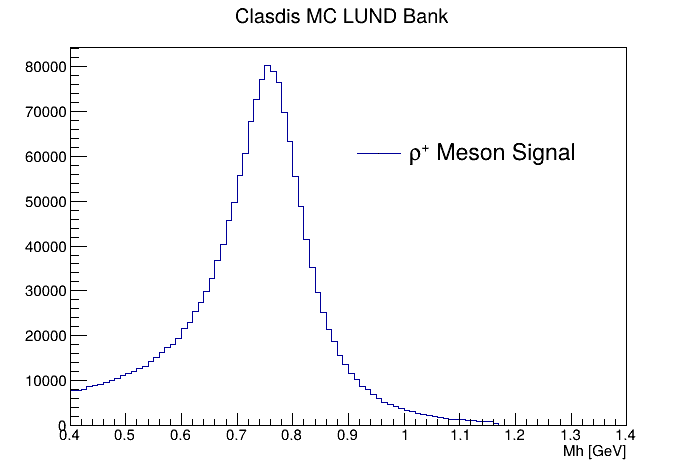

In [7]:
c = ROOT.TCanvas()
t.Draw("rho_M>>h(100,0.4,1.4)")
h = ROOT.gDirectory.Get("h")
h.SetStats(0)
h.SetTitle("Clasdis MC LUND Bank")
h.GetXaxis().SetTitle("Mh [GeV]")
h.Draw("HIST")
leg = ROOT.TLegend(0.5,0.5,0.85,0.85)
leg.AddEntry(h,"#rho^{+} Meson Signal")
leg.SetBorderSize(0)
leg.Draw()
c.Draw()

In [82]:
t_bins = [-5,-2.32,-1.65,-1.22,-0.94,-0.71,-0.55,-0.4,-0.27,0]

nbins = len(t_bins)-1
baseColor = 51
histograms = []
histograms_ex = []
for i in range(nbins):
    print(f"loading bin {i+1}")
    binCut = ROOT.TCut(f"{t_bins[i]}<t&&t<{t_bins[i+1]}")
    
    cut = binCut
    t.Draw(f"rho_M>>h{i}(100,0.4,1.4)",cut,"goff")
    hist = ROOT.gDirectory.Get(f"h{i}")
    hist.SetLineWidth(2)
    hist.SetTitle(f"{t_bins[i]} < t < {t_bins[i+1]}")
    histograms.append(hist)

    cut_ex = binCut + MxCut
    t.Draw(f"rho_M>>h{i}_ex(100,0.4,1.4)",cut_ex,"goff")
    hist_ex = ROOT.gDirectory.Get(f"h{i}_ex")
    hist_ex.SetLineWidth(2)
    hist_ex.SetLineColor(ROOT.kRed)
    hist_ex.SetTitle(f"{t_bins[i]} < t < {t_bins[i+1]}")
    histograms_ex.append(hist_ex)
    
    print(f"Percent of total Events: {round(hist.GetEntries() / t.GetEntries()*100,1)} % ")

loading bin 1
Percent of total Events: 42.6 % 
loading bin 2
Percent of total Events: 15.9 % 
loading bin 3
Percent of total Events: 10.3 % 
loading bin 4
Percent of total Events: 6.4 % 
loading bin 5
Percent of total Events: 4.5 % 
loading bin 6
Percent of total Events: 2.7 % 
loading bin 7
Percent of total Events: 2.3 % 
loading bin 8
Percent of total Events: 1.7 % 
loading bin 9
Percent of total Events: 1.1 % 


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


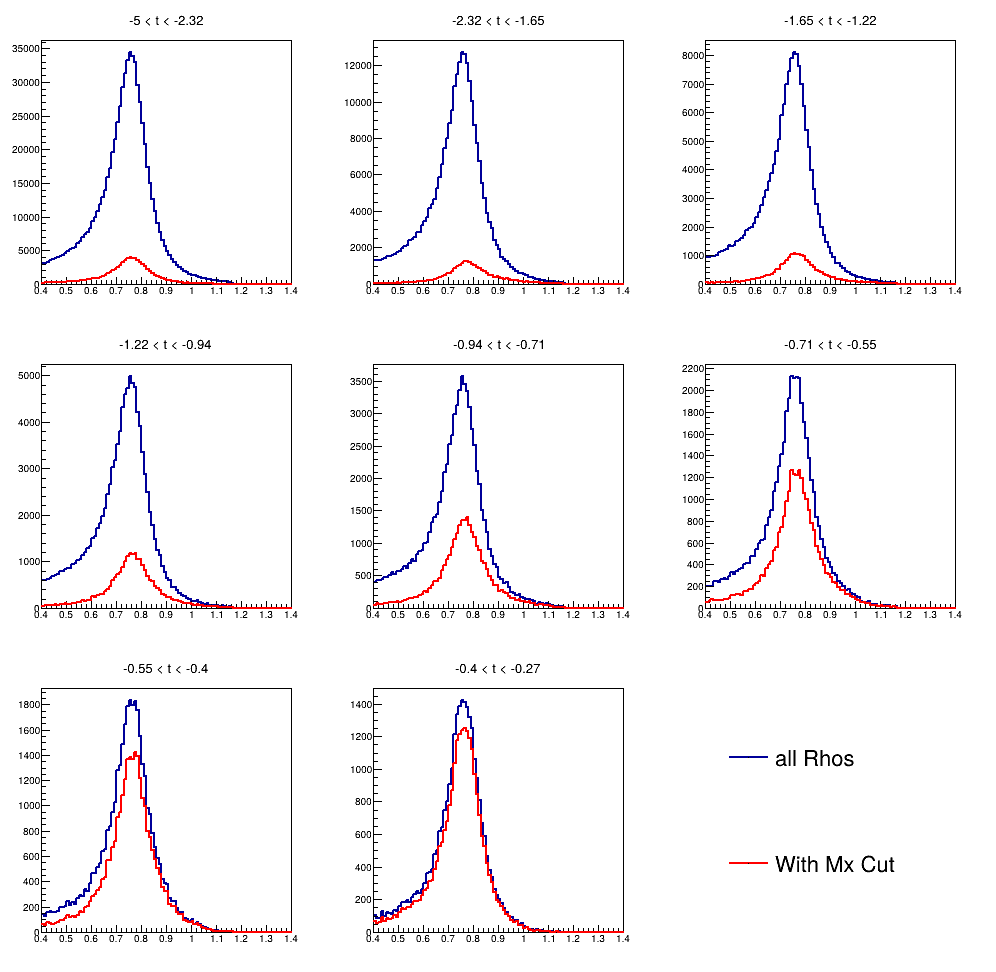

In [84]:
c = ROOT.TCanvas("c","c",1000,1000)
c.Divide(3,3)
draw_opt = "HIST"
for i in range(8):
    c.cd(i+1)
    histograms[i].SetStats(0)
    histograms[i].Draw(draw_opt)
    draw_opt = "HIST SAME"
    histograms_ex[i].Draw(draw_opt)

c.cd(9)
leg = ROOT.TLegend(0.15,0.15,0.85,0.85)
leg.AddEntry(histograms[0],"all Rhos")
leg.AddEntry(histograms_ex[0], "With Mx Cut")
leg.SetBorderSize(0)
leg.Draw()
c.Draw()

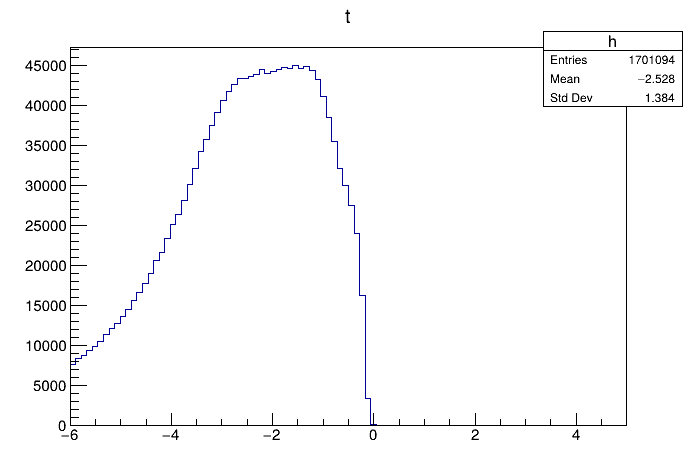

In [40]:
c = ROOT.TCanvas()
t.Draw("t>>h(100,-6,5)")
c.Draw()

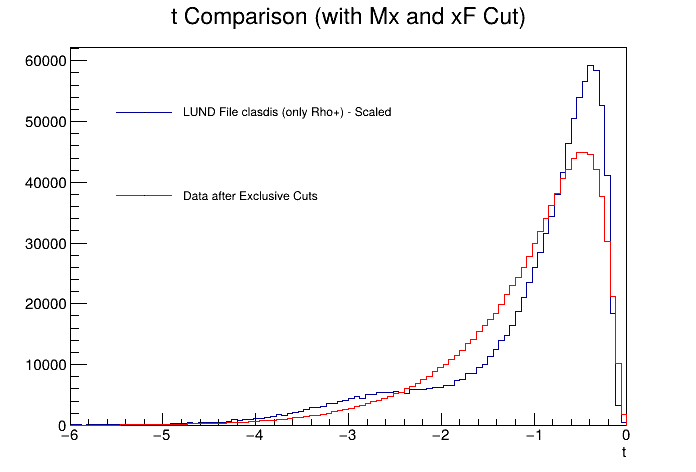

In [6]:
c = ROOT.TCanvas()
var = "t"
var_d = "t_elec"
t.Draw(f"{var}>>h(100,-6,0)",MxCut + xFCut)
pippi0.Draw(f"{var_d}>>hd(100,-6,0)")
h = ROOT.gDirectory.Get("h")
hd = ROOT.gDirectory.Get("hd")

h.Scale(hd.Integral()/h.Integral())
hd.SetLineColor(ROOT.kRed)
h.SetStats(0)
h.GetXaxis().SetTitle(var)
h.SetTitle("t Comparison (with Mx and xF Cut)")
h.Draw("HIST")
hd.Draw("HIST SAME")

leg = ROOT.TLegend(0.15,0.5,0.6,0.85)
leg.AddEntry(h,"LUND File clasdis (only Rho+) - Scaled")
leg.AddEntry(hd,"Data after Exclusive Cuts")
leg.SetBorderSize(0)
leg.Draw()
c.Draw()

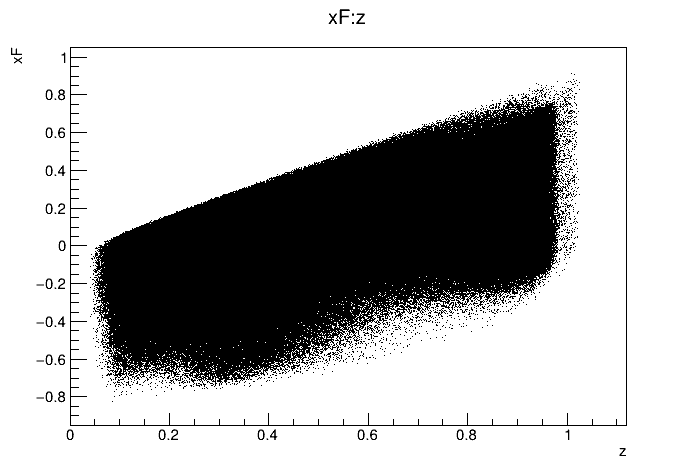

In [17]:
c = ROOT.TCanvas()
var = "Mx"
var_d = "Mx"
t.Draw(f"{var}>>h(100,0,3)")
pippi0.Draw(f"{var_d}>>hd(100,0,3)")
h = ROOT.gDirectory.Get("h")
hd = ROOT.gDirectory.Get("hd")

h.Scale(hd.Integral()/h.Integral())
hd.SetLineColor(ROOT.kRed)
hd.SetStats(0)
hd.GetXaxis().SetTitle(var)
hd.SetTitle("Ensuring the neutron parent pid is not a delta")
hd.Draw("HIST")
h.Draw("HIST SAME")

leg = ROOT.TLegend(0.5,0.5,0.85,0.85)
leg.AddEntry(h,"LUND File clasdis (only Rho+) - Scaled")
leg.AddEntry(hd,"Data after Exclusive Cuts")
leg.SetBorderSize(0)
leg.Draw()
c.Draw()

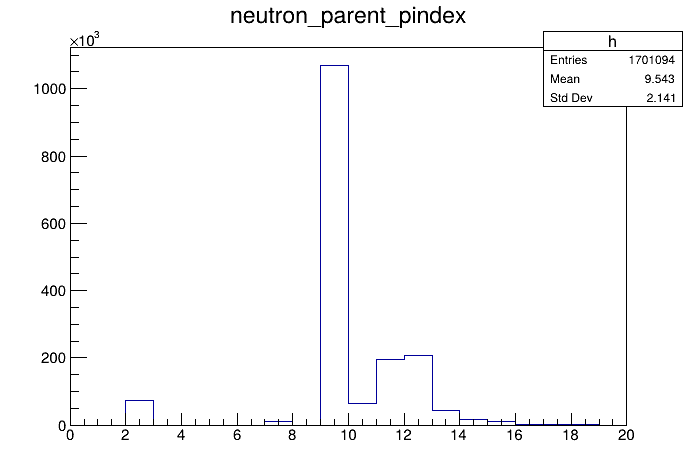

In [90]:
c = ROOT.TCanvas()
t.Draw("neutron_parent_pindex>>h(20,0,20)")
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


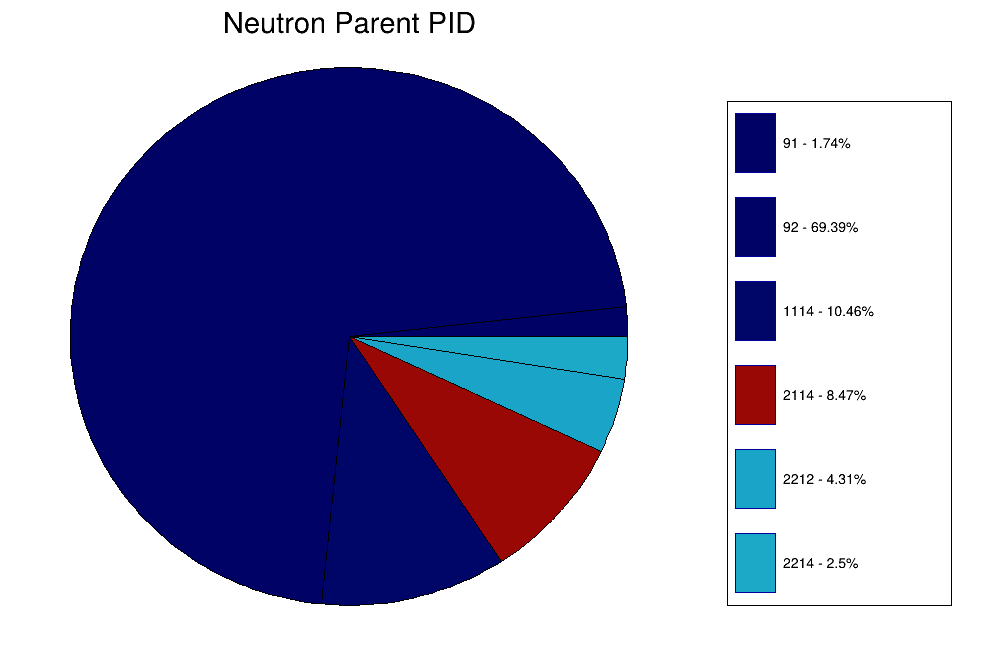

In [11]:
c = ROOT.TCanvas("c","c",1000,700)
c.Divide(2,1)
pad1 = c.cd(1)
pad1.SetPad(0.0,0.0,0.7,1.0)
pad1 = c.cd(2)
pad1.SetPad(0.7,0.0,1.0,1.0)

ROOT.gStyle.SetPalette(ROOT.kRainbow)
t.Draw("neutron_parent_pid>>h2(2210,90,2300)",WCut,"goff")
h2 = ROOT.gDirectory.Get("h2")
pie = ROOT.TPie("pie","Neutron Parent PID", h2.GetNbinsX())

dummyhists = []
leg = ROOT.TLegend(0.1,0.1,0.85,0.85)
for i in range (1, h2.GetNbinsX()+1):
    count = h2.GetBinContent(i)
    if count<1:
        continue

    pid_val = int(h2.GetBinCenter(i))
    pie.SetEntryVal(i-1,count)
    pie.SetEntryLabel(i-1,str(pid_val))
    temp = ROOT.TH1F(f"h_{i}","dummy hist",100,0,1)
    temp.SetFillColor(pie.GetEntryFillColor(i-1))
    dummyhists.append(temp)
    leg.AddEntry(temp,f"{pid_val} - {round(count/h2.GetEntries()*100,2)}%","f")

pie.SetRadius(0.4)
pie.SetLabelFormat("")
leg.SetTextSize(0.05)
c.cd(1)
pie.Draw()
c.cd(2)
leg.Draw()
c.Draw()

In [22]:

t.Draw("xF:z")


1701094.0

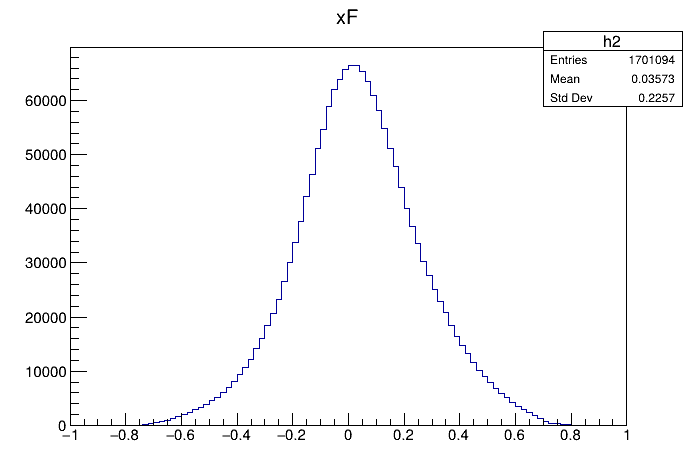

In [20]:
c = ROOT.TCanvas()
c.cd()

t.Draw("xF>>h2(100,-1,1)")
h2 = ROOT.gDirectory.Get("h2")
h2.Draw("COLZ")

c.Update()